# Fase 4 — Reporte analítico integrador

**Sobreduración en la titulación de la educación superior chilena (2020-2025)**

Programación para la Ciencia de Datos (202682.1927) · Magíster en Ciencia de Datos e
Inteligencia Artificial · Universidad Andrés Bello · Sebastian Antunez Noguera

---

Este notebook cierra el proyecto. No repite el trabajo de las fases anteriores: lo
**invoca**. El pipeline de limpieza y transformación es el de la Fase 2
(`src/pipeline.py`); los algoritmos, las métricas y los modelos son los de la Fase 3
(`src/nucleo/`). Aquí se ejecutan de extremo a extremo, se producen los resultados
finales y se discuten a la luz de la pregunta que originó el proyecto.

| Fase | Aporte | Dónde vive |
|------|--------|------------|
| F1 | Definición del problema, entorno reproducible, convenciones | `F1/`, `requirements.txt`, `src/config.py` |
| F2 | Ingesta de 6 CSV del SIES, limpieza, transformación, validación | `F2/`, `src/{ingesta,limpieza,transformacion,validacion,pipeline}.py` |
| F3 | Núcleo algorítmico, mediciones de complejidad, POO, modelos | `F3/`, `src/nucleo/` |
| **F4** | **Análisis final, visualizaciones, discusión y comunicación** | **este notebook** |

**Pregunta que guía el proyecto.** ¿Cuánto se demoran realmente los estudiantes
chilenos en titularse respecto de lo que declara su plan de estudios, y qué factores
institucionales, territoriales y demográficos se asocian a esa diferencia?

**Cómo ejecutarlo.** *Kernel → Restart Kernel and Run All Cells*. Tarda entre 4 y 7
minutos con el dataset completo. Si el Parquet de la Fase 2 no existe, la fachada
degrada automáticamente a la muestra versionada de 5.000 registros y lo informa.

## 1. Entorno y reproducibilidad

La reproducibilidad no es una declaración: es una comprobación. Esta sección deja
registro de las versiones exactas con las que se generaron los resultados y del origen
de los datos utilizados.

In [1]:
# Celda de arranque: hace importable el paquete `src` sin instalar el proyecto
# y funciona igual si el notebook se abre desde la raiz o desde su subcarpeta.
import sys
from pathlib import Path

RAIZ = Path.cwd()
if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

from src import config

print("Raiz del proyecto:", RAIZ)
for clave, valor in config.describir_entorno().items():
    print(f"  {clave:12s} {valor}")

Raiz del proyecto: D:\Magister Ciencia de Datos\Programacion para la Ciencia\Sumativas\proyecto-titulados
  python       3.14.7
  plataforma   Windows-11-10.0.26200-SP0
  ejecutable   C:\Users\Sebastian Antunez N\AppData\Local\Programs\Python\Python314\python.exe
  numpy        2.5.3
  pandas       3.0.5
  matplotlib   3.11.1
  seaborn      0.13.2
  pyarrow      25.0.1


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

from src import viz
from src.nucleo.fachada import NucleoAnalitico

viz.aplicar_estilo()
INICIO = time.perf_counter()

nucleo = NucleoAnalitico(limite_cohorte=300_000, semilla=42)
df = nucleo.datos

print(f"Origen de los datos: {nucleo.origen_datos}")
print(f"Registros: {len(df):,} | columnas: {df.shape[1]}".replace(",", "."))
print(f"Periodo cubierto: {int(df['anio_titulo'].min())}-{int(df['anio_titulo'].max())}")

Origen de los datos: completo
Registros: 1.246.760 | columnas: 47
Periodo cubierto: 2020-2026


### 1.1 Verificación del entorno

El proyecto declara sus dependencias con versión fijada en `requirements.txt`. La celda
siguiente comprueba que las instaladas coinciden: si alguna difiere, los resultados
podrían no reproducirse exactamente y conviene saberlo antes de interpretarlos.

In [3]:
import importlib.metadata as md_meta
import re

requeridas = {}
for linea in (RAIZ / "requirements.txt").read_text(encoding="utf-8").splitlines():
    linea = linea.split("#")[0].strip()
    if "==" in linea:
        nombre, version = linea.split("==")
        requeridas[nombre.strip()] = version.strip()

filas = []
for paquete, esperada in requeridas.items():
    try:
        instalada = md_meta.version(paquete)
    except md_meta.PackageNotFoundError:
        instalada = "NO INSTALADO"
    filas.append({"paquete": paquete, "requerida": esperada, "instalada": instalada,
                  "coincide": instalada == esperada})

entorno = pd.DataFrame(filas)
print(entorno.to_string(index=False))
print(f"\nPython {sys.version.split()[0]}")
print(f"Dependencias que coinciden: {entorno['coincide'].sum()} de {len(entorno)}")

   paquete requerida    instalada  coincide
     numpy     2.5.3        2.5.3      True
    pandas     3.0.5        3.0.5      True
   pyarrow    25.0.1       25.0.1      True
matplotlib    3.11.1       3.11.1      True
   seaborn    0.13.2       0.13.2      True
jupyterlab     4.6.3        4.6.3      True
  notebook     7.6.2 NO INSTALADO     False
 ipykernel     7.3.0        7.3.0      True
  nbformat    5.11.1       5.11.1      True
 nbconvert    7.17.1       7.17.1      True
    pytest     9.1.1        9.1.1      True

Python 3.14.7
Dependencias que coinciden: 10 de 11


## 2. Recorrido del proyecto: de los CSV crudos al dataset analítico

El punto de partida fueron seis archivos CSV del Servicio de Información de Educación
Superior (SIES), uno por año entre 2020 y 2025: 955 MB, 1.710.167 filas y 40 columnas,
separados por punto y coma y codificados en UTF-8.

El hallazgo que definió el proyecto apareció al leer el diccionario de variables: las
columnas `dur_estudio_carr`, `dur_proceso_tit` y `dur_total_carr` **no** registran lo
que el estudiante tardó, sino lo que el plan de estudios declara. La duración real no
existe como variable y hubo que reconstruirla:

```python
duracion_real_sem = (anio_titulo - anio_ing_carr_ori) * 2 \
                    + (semestre_titulo - sem_ing_carr_ori) + 1
sobreduracion_sem = duracion_real_sem - dur_total_carr
```

Sobre esa variable derivada se construye todo el análisis. La tabla siguiente resume el
pipeline de la Fase 2, que este notebook reutiliza sin modificar.

In [4]:
pipeline_f2 = pd.DataFrame([
    ("1. Ingesta", "Lectura de 6 CSV con dtypes declarados y validación de esquema",
     "1.710.167 filas", "Declarar tipos evita inferencias erróneas y reduce memoria"),
    ("2. Centinelas", "9995/9998/9999/1900, 19000101 y semestre 0 convertidos a NA",
     "62.492 en año de ingreso", "Procesados como números darían duraciones imposibles"),
    ("3. Normalización", "18 columnas categóricas homogeneizadas sobre su catálogo",
     "8,6 millones de celdas", "Evita categorías duplicadas por capitalización"),
    ("4. Pregrado", "Filtro nivel_global == Pregrado",
     "398.391 excluidos", "Posgrado no es comparable en duración teórica"),
    ("5. Duplicados", "Clave estudiante + carrera + fecha de titulación",
     "72 eliminados", "Dos nulos no deben tratarse como iguales"),
    ("6. Sin insumos", "Filas sin año o semestre de ingreso utilizable",
     "61.825 (4,7 %)", "Imputar el inicio equivaldría a inventar la variable objetivo"),
    ("7. Derivación", "Duración real, sobreduración, índice, edad, categoría de rezago",
     "1.246.760 finales", "Enteros exactos: sin errores de redondeo al comparar"),
    ("8. Atípicos", "Fuera de [1, 40] semestres o edad fuera de [15, 90]",
     "3.119 (0,25 %) marcados", "Se marcan, no se eliminan: la decisión queda visible"),
], columns=["Paso", "Tratamiento", "Efecto", "Justificación técnica"])

print(pipeline_f2.to_string(index=False, max_colwidth=46))
print(f"\nRetención final: {len(df):,} de 1.710.167 filas ({100*len(df)/1_710_167:.1f} %)".replace(",", "."))

            Paso                                    Tratamiento                   Efecto                          Justificación técnica
      1. Ingesta Lectura de 6 CSV con dtypes declarados y va...          1.710.167 filas Declarar tipos evita inferencias erróneas y...
   2. Centinelas 9995/9998/9999/1900, 19000101 y semestre 0 ... 62.492 en año de ingreso Procesados como números darían duraciones i...
3. Normalización 18 columnas categóricas homogeneizadas sobr...   8,6 millones de celdas Evita categorías duplicadas por capitalización
     4. Pregrado                Filtro nivel_global == Pregrado        398.391 excluidos  Posgrado no es comparable en duración teórica
   5. Duplicados Clave estudiante + carrera + fecha de titul...            72 eliminados       Dos nulos no deben tratarse como iguales
  6. Sin insumos Filas sin año o semestre de ingreso utilizable           61.825 (4,7 %) Imputar el inicio equivaldría a inventar la...
   7. Derivación Duración real, sobreduración, í

### 2.1 Transformaciones aplicadas en esta fase

La Fase 4 no vuelve a limpiar: hereda el dataset validado y solo deriva las agrupaciones
que el análisis final requiere. Cada una se justifica abajo y ninguna altera los datos
de origen.

In [5]:
# Las tres agrupaciones que usa el análisis final. Se derivan aquí, no se
# persisten: el dataset de la Fase 2 permanece intacto y trazable.
analisis = df.copy()

# (a) Duración teórica en tramos: permite comparar carreras cortas y largas
#     sin que la escala de la carrera domine la comparación.
analisis["tramo_teorico"] = pd.cut(
    analisis["dur_total_carr"].astype("float64"),
    bins=[0, 8, 10, 12, 100],
    labels=["Hasta 8 sem.", "9-10 sem.", "11-12 sem.", "Más de 12 sem."],
)

# (b) Década de ingreso: agrupa cohortes con horizonte de titulación comparable.
analisis["periodo_ingreso"] = pd.cut(
    analisis["cohorte_ingreso"].astype("float64"),
    bins=[1999, 2009, 2014, 2019, 2030],
    labels=["Antes de 2010", "2010-2014", "2015-2019", "2020 o después"],
)

# (c) Indicador de titulación anticipada: el 4,1 % que egresa antes del plazo
#     teórico es un fenómeno propio (convalidaciones, cambios de carrera) que
#     conviene poder aislar en las lecturas.
analisis["titulacion_anticipada"] = analisis["sobreduracion_sem"] < 0

resumen_transf = pd.DataFrame({
    "transformación": ["tramo_teorico", "periodo_ingreso", "titulacion_anticipada"],
    "tipo": ["discretización", "discretización", "indicador booleano"],
    "categorías": [analisis["tramo_teorico"].nunique(),
                   analisis["periodo_ingreso"].nunique(), 2],
    "sin dato": [int(analisis["tramo_teorico"].isna().sum()),
                 int(analisis["periodo_ingreso"].isna().sum()), 0],
})
print(resumen_transf.to_string(index=False))
print(f"\nTitulación anticipada: {analisis['titulacion_anticipada'].sum():,} casos "
      f"({100*analisis['titulacion_anticipada'].mean():.1f} %)".replace(",", "."))

assert len(analisis) == len(df), "las transformaciones no deben alterar el número de filas"
assert analisis["sobreduracion_sem"].equals(df["sobreduracion_sem"]), "la variable objetivo no se modifica"
print("\nVerificado: mismo número de filas y variable objetivo intacta.")

       transformación               tipo  categorías  sin dato
        tramo_teorico     discretización           4         0
      periodo_ingreso     discretización           4         0
titulacion_anticipada indicador booleano           2         0

Titulación anticipada: 51.326 casos (4.1 %)

Verificado: mismo número de filas y variable objetivo intacta.


## 3. Resultados

### 3.1 Panorama general

Los indicadores que responden directamente a la pregunta del proyecto.

In [6]:
n = len(analisis)
indicadores = pd.DataFrame([
    ("Titulados de pregrado analizados", f"{n:,}".replace(",", "."), ""),
    ("Sobreduración media", f"{analisis['sobreduracion_sem'].mean():.2f}", "semestres"),
    ("Sobreduración mediana", f"{analisis['sobreduracion_sem'].median():.1f}", "semestres"),
    ("Índice de duración medio", f"{analisis['indice_duracion'].mean():.2f}", "real / teórica"),
    ("Titulación oportuna", f"{100*analisis['titulacion_oportuna'].mean():.1f}", "%"),
    ("Rezago severo (> 4 semestres)", f"{100*(analisis['sobreduracion_sem'] > 4).mean():.1f}", "%"),
    ("Titulación anticipada", f"{100*analisis['titulacion_anticipada'].mean():.1f}", "%"),
    ("Semestres-estudiante en exceso", f"{int(analisis['sobreduracion_sem'].clip(lower=0).sum()):,}".replace(",", "."), "acumulados"),
], columns=["Indicador", "Valor", "Unidad"])

print(indicadores.to_string(index=False))
indicadores.to_csv(RAIZ / "reports" / "tables" / "f4_indicadores_finales.csv", index=False, encoding="utf-8")

                       Indicador     Valor         Unidad
Titulados de pregrado analizados 1.246.760               
             Sobreduración media      2.76      semestres
           Sobreduración mediana       1.0      semestres
        Índice de duración medio      1.43 real / teórica
             Titulación oportuna      19.0              %
   Rezago severo (> 4 semestres)      20.4              %
           Titulación anticipada       4.1              %
  Semestres-estudiante en exceso 3.551.990     acumulados


El resultado central es contundente: **solo 1 de cada 5 titulados egresa dentro del
plazo que su propio plan de estudios declara**. El estudiante promedio cursa un 43 % más
de tiempo del previsto. Agregado, el sistema acumula 3.551.990
semestres-estudiante por sobre lo planificado en el período 2020-2025.

### 3.2 Figura 1 — Distribución de la sobreduración

Antes de comparar grupos hay que conocer la forma de la variable. Un promedio sobre una
distribución muy asimétrica puede ocultar más de lo que muestra.

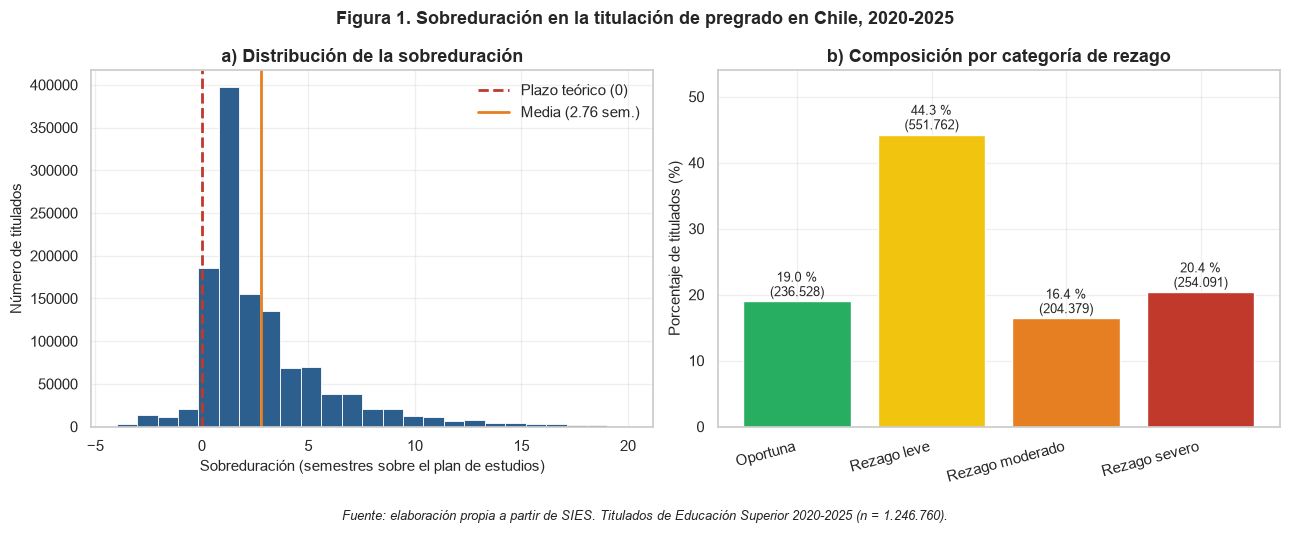

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel izquierdo: histograma de la sobreduración ---------------------
valores = analisis["sobreduracion_sem"].astype("float64")
recorte = valores[(valores >= -4) & (valores <= 20)]
ax1.hist(recorte, bins=25, color="#2C5F8D", edgecolor="white", linewidth=0.6)
ax1.axvline(0, color="#C0392B", linestyle="--", linewidth=2, label="Plazo teórico (0)")
ax1.axvline(valores.mean(), color="#E67E22", linestyle="-", linewidth=2,
            label=f"Media ({valores.mean():.2f} sem.)")
ax1.set_xlabel("Sobreduración (semestres sobre el plan de estudios)")
ax1.set_ylabel("Número de titulados")
ax1.set_title("a) Distribución de la sobreduración")
ax1.legend()

# --- Panel derecho: composición por categoría de rezago ------------------
orden = ["Oportuna", "Rezago leve", "Rezago moderado", "Rezago severo"]
conteo = analisis["categoria_rezago"].value_counts().reindex(orden)
porcentaje = 100 * conteo / conteo.sum()
colores = ["#27AE60", "#F1C40F", "#E67E22", "#C0392B"]
barras = ax2.bar(range(len(orden)), porcentaje.to_numpy(), color=colores)
ax2.set_xticks(range(len(orden)))
ax2.set_xticklabels(orden, rotation=15, ha="right")
ax2.set_ylabel("Porcentaje de titulados (%)")
ax2.set_title("b) Composición por categoría de rezago")
for barra, pct, cnt in zip(barras, porcentaje, conteo):
    ax2.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.8,
             f"{pct:.1f} %\n({cnt:,.0f})".replace(",", "."), ha="center", fontsize=9)
ax2.set_ylim(0, porcentaje.max() * 1.22)

fig.suptitle("Figura 1. Sobreduración en la titulación de pregrado en Chile, 2020-2025",
             fontsize=13, fontweight="bold")
fig.text(0.5, -0.04, f"Fuente: elaboración propia a partir de SIES, Titulados de Educación "
         f"Superior 2020-2025 (n = {n:,}).".replace(",", "."), ha="center", fontsize=9, style="italic")
fig.tight_layout()
viz.guardar(fig, "f4_distribucion_sobreduracion")
plt.show()

La distribución tiene una asimetría marcada a la derecha: la mayoría se concentra en
rezagos de uno a tres semestres, pero una cola larga arrastra la media por encima de la
mediana. Por eso el informe reporta ambas: la media (2,76) dimensiona el costo agregado,
la mediana (1,0) describe al estudiante típico, y la distancia entre ambas mide
precisamente el peso de la cola de rezago severo.

La composición confirma la magnitud del fenómeno: **el rezago severo —más de cuatro
semestres de exceso— alcanza a uno de cada cinco titulados**, la misma proporción que
logra titularse en plazo.

### 3.3 Figura 2 — Dónde se concentra el rezago

Tres cortes simultáneos: área de conocimiento, tipo de institución y género. Responden a
la pregunta de si el rezago es homogéneo o si hay grupos sistemáticamente más afectados.

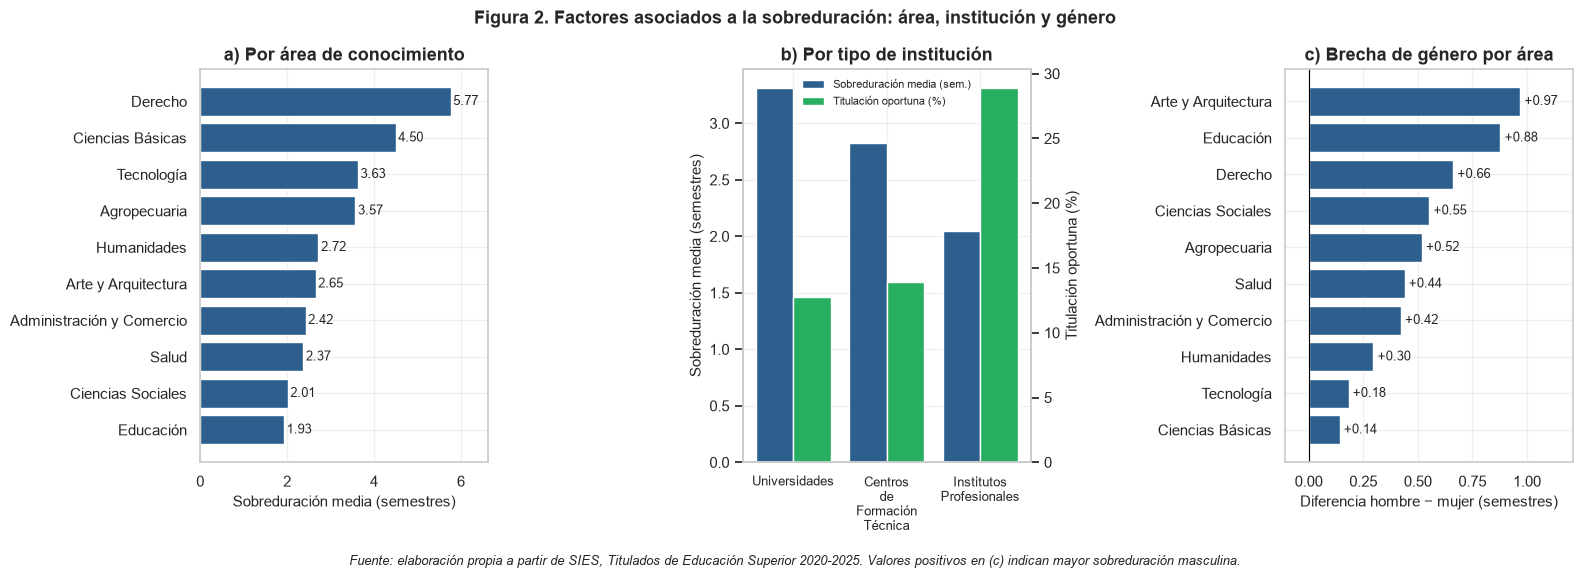

Razón Derecho / Educación: 2.99
Brecha de género global: 0.93 semestres
Áreas con brecha favorable a las mujeres: 10 de 10


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# --- (a) por area de conocimiento ----------------------------------------
por_area = analisis.groupby("area_conocimiento", observed=True)["sobreduracion_sem"].mean().sort_values()
axes[0].barh(por_area.index.astype(str), por_area.to_numpy(), color="#2C5F8D")
axes[0].set_xlabel("Sobreduración media (semestres)")
axes[0].set_title("a) Por área de conocimiento")
for i, v in enumerate(por_area):
    axes[0].text(v + 0.06, i, f"{v:.2f}", va="center", fontsize=9)
axes[0].set_xlim(0, por_area.max() * 1.15)

# --- (b) por tipo de institucion -----------------------------------------
por_tipo = analisis.groupby("tipo_inst_1", observed=True).agg(
    media=("sobreduracion_sem", "mean"), oportuna=("titulacion_oportuna", "mean")
).sort_values("media", ascending=False)
x = np.arange(len(por_tipo))
axes[1].bar(x - 0.2, por_tipo["media"], width=0.4, color="#2C5F8D", label="Sobreduración media (sem.)")
eje2 = axes[1].twinx()
eje2.bar(x + 0.2, 100 * por_tipo["oportuna"], width=0.4, color="#27AE60", label="Titulación oportuna (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels([t.replace(" ", "\n") for t in por_tipo.index.astype(str)], fontsize=9)
axes[1].set_ylabel("Sobreduración media (semestres)")
eje2.set_ylabel("Titulación oportuna (%)")
eje2.grid(False)
axes[1].set_title("b) Por tipo de institución")
lineas1, etiquetas1 = axes[1].get_legend_handles_labels()
lineas2, etiquetas2 = eje2.get_legend_handles_labels()
axes[1].legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper center", fontsize=8)

# --- (c) brecha de genero por area ---------------------------------------
brecha = analisis.pivot_table(index="area_conocimiento", columns="genero",
                              values="sobreduracion_sem", aggfunc="mean", observed=True)
brecha["diferencia"] = brecha["Hombre"] - brecha["Mujer"]
brecha = brecha.sort_values("diferencia")
colores_b = ["#C0392B" if d < 0 else "#2C5F8D" for d in brecha["diferencia"]]
axes[2].barh(brecha.index.astype(str), brecha["diferencia"].to_numpy(), color=colores_b)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_xlabel("Diferencia hombre − mujer (semestres)")
axes[2].set_title("c) Brecha de género por área")
for i, v in enumerate(brecha["diferencia"]):
    axes[2].text(v + (0.02 if v >= 0 else -0.02), i, f"{v:+.2f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=9)
axes[2].set_xlim(brecha["diferencia"].min() - 0.25, brecha["diferencia"].max() * 1.25)

fig.suptitle("Figura 2. Factores asociados a la sobreduración: área, institución y género",
             fontsize=13, fontweight="bold")
fig.text(0.5, -0.03, "Fuente: elaboración propia a partir de SIES, Titulados de Educación Superior "
         "2020-2025. Valores positivos en (c) indican mayor sobreduración masculina.",
         ha="center", fontsize=9, style="italic")
fig.tight_layout()
viz.guardar(fig, "f4_factores_sobreduracion")
plt.show()

print(f"Razón Derecho / Educación: {por_area.max() / por_area.min():.2f}")
print(f"Brecha de género global: {analisis[analisis.genero=='Hombre'].sobreduracion_sem.mean() - analisis[analisis.genero=='Mujer'].sobreduracion_sem.mean():.2f} semestres")
print(f"Áreas con brecha favorable a las mujeres: {(brecha['diferencia'] > 0).sum()} de {len(brecha)}")

Los tres cortes muestran que el rezago **no es homogéneo**:

- **Área de conocimiento.** Derecho triplica a Educación. La diferencia no es marginal:
  son casi cuatro semestres —dos años— de distancia entre la carrera más rezagada y la
  menos rezagada.
- **Tipo de institución.** Las universidades acumulan más sobreduración que los IP y los
  CFT, y su tasa de titulación oportuna es menor. Planes más largos y exigentes producen
  más rezago, lo que sugiere que la duración teórica declarada es menos realista en
  carreras universitarias.
- **Género.** Las mujeres se titulan antes en prácticamente todas las áreas. La brecha
  global es de casi un semestre y su consistencia entre áreas descarta que se explique
  por la composición de carreras.

### 3.4 Figura 3 — Evolución temporal y efecto de la pandemia

La serie semestral revela un patrón que los promedios agregados ocultan por completo.

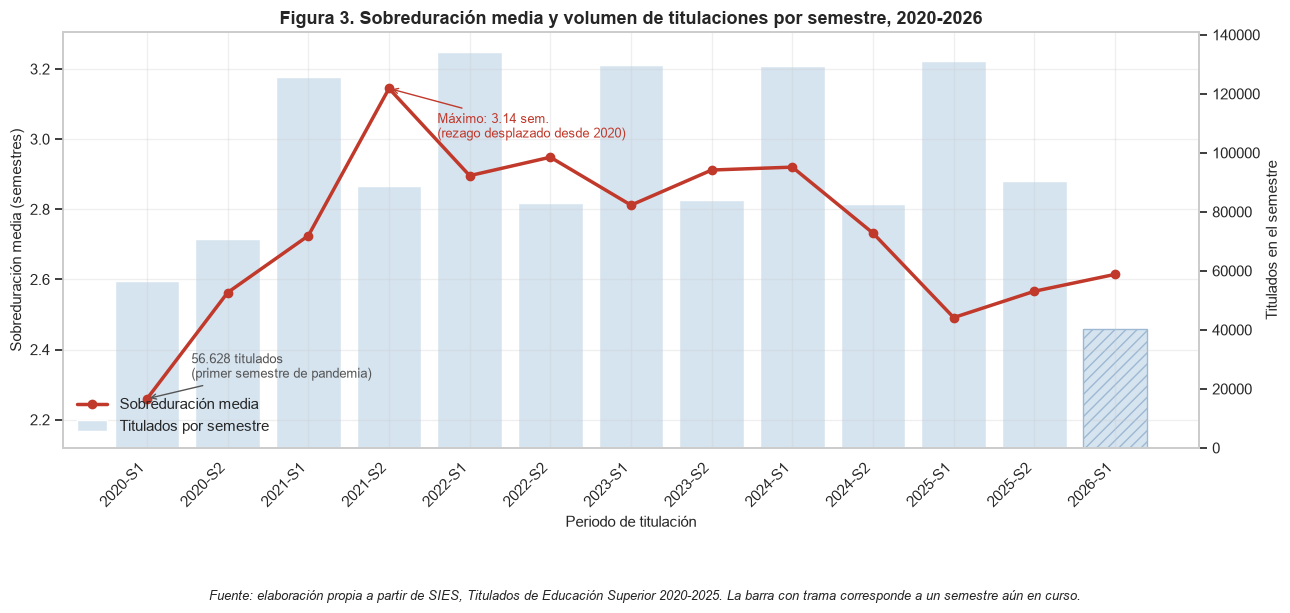

periodo  titulados  media  oportuna
2020-S1      56628   2.26      0.25
2020-S2      70738  2.562     0.154
2021-S1     125733  2.725     0.183
2021-S2      88684  3.144     0.125
2022-S1     134119  2.896     0.178
2022-S2      83104  2.948     0.185
2023-S1     129598  2.812     0.192
2023-S2      84084  2.912     0.193
2024-S1     129542   2.92     0.202
2024-S2      82572  2.732     0.225
2025-S1     131210  2.491     0.204
2025-S2      90302  2.566     0.236
2026-S1      40446  2.614     0.099


In [9]:
serie = analisis.groupby(["anio_titulo", "semestre_titulo"], observed=True).agg(
    media=("sobreduracion_sem", "mean"),
    titulados=("sobreduracion_sem", "size"),
    oportuna=("titulacion_oportuna", "mean"),
).reset_index()
serie["periodo"] = serie["anio_titulo"].astype(int).astype(str) + "-S" + serie["semestre_titulo"].astype(int).astype(str)
serie = serie.sort_values(["anio_titulo", "semestre_titulo"]).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax2 = ax1.twinx()

ax2.bar(range(len(serie)), serie["titulados"], color="#D6E4F0", label="Titulados por semestre")
ax2.set_ylabel("Titulados en el semestre")
ax2.grid(False)

ax1.plot(range(len(serie)), serie["media"], marker="o", color="#C0392B",
         linewidth=2.5, label="Sobreduración media")
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)
ax1.set_xticks(range(len(serie)))
ax1.set_xticklabels(serie["periodo"], rotation=45, ha="right")
ax1.set_ylabel("Sobreduración media (semestres)")
ax1.set_xlabel("Periodo de titulación")

# El ultimo periodo esta incompleto (el semestre aun no termina): se marca
# con trama para que no se lea como una caida real de titulaciones.
ax2.patches[-1].set_hatch("///")
ax2.patches[-1].set_edgecolor("#9DB8D2")

pico = int(serie["media"].idxmax())
ax1.annotate(f"Máximo: {serie.loc[pico, 'media']:.2f} sem.\n(rezago desplazado desde 2020)",
             xy=(pico, serie.loc[pico, "media"]),
             xytext=(pico + 0.6, serie.loc[pico, "media"] - 0.14),
             arrowprops=dict(arrowstyle="->", color="#C0392B"), fontsize=9, color="#C0392B")

# La caida corresponde al primer semestre de pandemia, no al periodo final
# incompleto: se localiza explicitamente por su etiqueta.
inicio_pandemia = int(serie.index[serie["periodo"] == "2020-S1"][0])
ax1.annotate(f"{serie.loc[inicio_pandemia, 'titulados']:,.0f} titulados\n(primer semestre de pandemia)".replace(",", "."),
             xy=(inicio_pandemia, serie.loc[inicio_pandemia, "media"]),
             xytext=(inicio_pandemia + 0.55, serie["media"].min() + 0.06),
             arrowprops=dict(arrowstyle="->", color="#555555"), fontsize=9, color="#555555")
ax1.set_ylim(serie["media"].min() - 0.14, serie["media"].max() + 0.16)

lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="lower left")
ax1.set_title("Figura 3. Sobreduración media y volumen de titulaciones por semestre, 2020-2026",
              fontsize=13, fontweight="bold")
fig.text(0.5, -0.10, "Fuente: elaboración propia a partir de SIES, Titulados de Educación Superior "
         "2020-2025. La barra con trama corresponde a un semestre aún en curso.", ha="center", fontsize=9, style="italic")
fig.tight_layout()
viz.guardar(fig, "f4_serie_temporal")
plt.show()

print(serie[["periodo", "titulados", "media", "oportuna"]].round(3).to_string(index=False))
serie.to_csv(RAIZ / "reports" / "tables" / "f4_serie_semestral.csv", index=False, encoding="utf-8")

El patrón es claro y no se había detectado en las fases anteriores: **en 2020 se
titularon unas 87.000 personas menos que en un año normal, y la sobreduración media tocó
su mínimo; en 2021 el volumen se recuperó y la sobreduración alcanzó su máximo.**

La lectura correcta no es que 2020 fuera un buen año. Es que las titulaciones se
**postergaron**: quienes debían egresar en 2020 lo hicieron en 2021 con uno o dos
semestres adicionales encima. El mínimo de 2020 y el máximo de 2021 son dos caras del
mismo fenómeno, y el mecanismo es de desplazamiento, no de deterioro académico.

Desde 2024 la serie desciende de forma sostenida. Ese descenso debe leerse con cautela
por la razón que se examina en la sección siguiente.

### 3.5 Figura 4 — El sesgo de truncamiento (limitación metodológica)

Una base de *titulados* solo contiene a quien terminó. Esa obviedad tiene una
consecuencia que condiciona la interpretación de todo lo anterior.

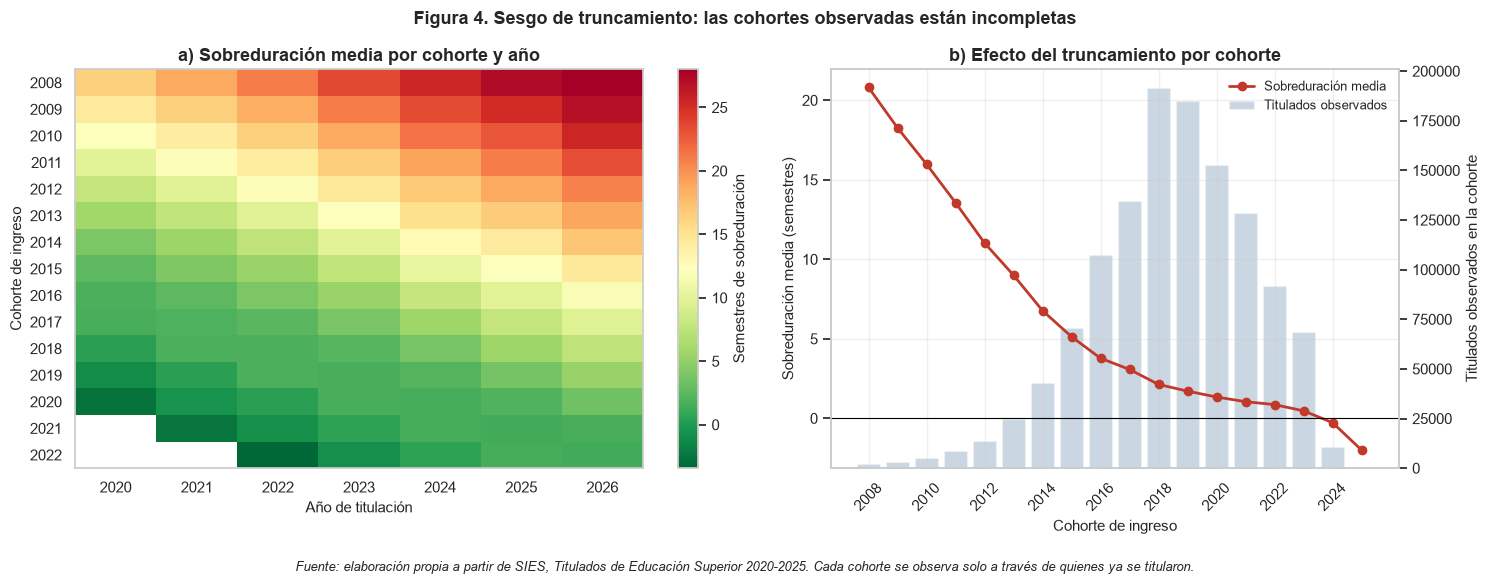

                 titulados  media
cohorte_ingreso                  
2016                107567   3.78
2017                134348   3.08
2018                191319   2.13
2019                184973   1.71
2020                152516   1.34
2021                128566   1.05
2022                 91665   0.86
2023                 68826   0.47
2024                 10734  -0.27
2025                   392  -1.99


In [10]:
matriz = analisis.pivot_table(index="cohorte_ingreso", columns="anio_titulo",
                              values="sobreduracion_sem", aggfunc="mean", observed=True)
matriz = matriz.loc[(matriz.index >= 2008) & (matriz.index <= 2022)]

por_cohorte = analisis.groupby("cohorte_ingreso", observed=True).agg(
    titulados=("sobreduracion_sem", "size"), media=("sobreduracion_sem", "mean")
)
por_cohorte = por_cohorte.loc[(por_cohorte.index >= 2008) & (por_cohorte.index <= 2025)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5),
                               gridspec_kw={"width_ratios": [1.25, 1]})

imagen = ax1.imshow(matriz.to_numpy(dtype="float64"), aspect="auto", cmap="RdYlGn_r")
ax1.set_xticks(range(len(matriz.columns)))
ax1.set_xticklabels([int(c) for c in matriz.columns])
ax1.set_yticks(range(len(matriz.index)))
ax1.set_yticklabels([int(i) for i in matriz.index])
ax1.set_xlabel("Año de titulación")
ax1.set_ylabel("Cohorte de ingreso")
ax1.set_title("a) Sobreduración media por cohorte y año")
ax1.grid(False)
fig.colorbar(imagen, ax=ax1, label="Semestres de sobreduración")

ax2.plot(por_cohorte.index.astype(int), por_cohorte["media"], marker="o",
         color="#C0392B", linewidth=2, label="Sobreduración media")
ax2.set_xlabel("Cohorte de ingreso")
ax2.set_ylabel("Sobreduración media (semestres)")
ax2.axhline(0, color="black", linewidth=0.8)
eje_b = ax2.twinx()
eje_b.bar(por_cohorte.index.astype(int), por_cohorte["titulados"], alpha=0.25,
          color="#2C5F8D", label="Titulados observados")
eje_b.set_ylabel("Titulados observados en la cohorte")
eje_b.grid(False)
ax2.set_zorder(eje_b.get_zorder() + 1)
ax2.patch.set_visible(False)
ax2.set_title("b) Efecto del truncamiento por cohorte")
# Las cohortes son anios: el eje no debe mostrar decimales.
ax2.set_xticks(range(int(por_cohorte.index.min()), int(por_cohorte.index.max()) + 1, 2))
ax2.tick_params(axis="x", rotation=45)
l1, e1 = ax2.get_legend_handles_labels()
l2, e2 = eje_b.get_legend_handles_labels()
ax2.legend(l1 + l2, e1 + e2, loc="upper right", fontsize=9)

fig.suptitle("Figura 4. Sesgo de truncamiento: las cohortes observadas están incompletas",
             fontsize=13, fontweight="bold")
fig.text(0.5, -0.04, "Fuente: elaboración propia a partir de SIES, Titulados de Educación Superior "
         "2020-2025. Cada cohorte se observa solo a través de quienes ya se titularon.",
         ha="center", fontsize=9, style="italic")
fig.tight_layout()
viz.guardar(fig, "f4_truncamiento_cohortes")
plt.show()

print(por_cohorte.round(2).tail(10).to_string())

El panel (b) muestra el problema con claridad: la sobreduración media **cae** de forma
monótona en las cohortes recientes hasta hacerse negativa. Sería un error celebrarlo
como una mejora del sistema.

De la cohorte 2024 solo se han titulado los excepcionalmente rápidos —los únicos que
alcanzaron a hacerlo—; de la cohorte 2008, en cambio, los que aparecen en una base de
2020-2025 son los extremadamente rezagados. **Ninguna cohorte está completa, y están
incompletas en direcciones opuestas.** El valor de una cohorte reciente subirá a medida
que sus estudiantes lentos se vayan titulando.

Es una limitación inherente al diseño de la fuente, no un defecto del procesamiento, y
condiciona toda lectura longitudinal: las comparaciones válidas son entre cohortes con
horizonte de titulación comparable —en la práctica, las anteriores a 2019—.

### 3.6 Modelación: qué explica la sobreduración

Los modelos de la Fase 3, implementados desde primeros principios con descenso de
gradiente, se ejecutan aquí sobre los datos completos para cuantificar la asociación de
cada factor.

In [11]:
resultado = nucleo.ajustar_modelos(limite=200_000, iteraciones=1500, tasa=0.5)

coeficientes = resultado.coeficientes()
print("--- Coeficientes (variables estandarizadas) ---")
print(coeficientes.round(3).to_string(index=False))

print("\n--- Desempeño en el conjunto de prueba ---")
desempeno = pd.DataFrame(resultado.metricas).T
print(desempeno.round(3).to_string())

base = 1 - analisis["titulacion_oportuna"].mean()
print(f"\nLínea base del clasificador (predecir siempre 'no oportuna'): {base:.3f}")

--- Coeficientes (variables estandarizadas) ---
                             variable  descenso_gradiente  solucion_cerrada  logistica  diferencia_abs
                       dur_total_carr              -0.382            -0.382      0.055           0.000
                         edad_ingreso              -0.525            -0.525      0.291           0.000
                         genero=Mujer              -0.405            -0.405      0.128           0.000
 tipo_inst_1=Institutos Profesionales              -0.544            -0.544      0.889           0.000
            tipo_inst_1=Universidades               0.916             0.916     -0.040           0.000
       area_conocimiento=Agropecuaria               0.712             0.712     -0.377           0.000
area_conocimiento=Arte y Arquitectura               0.002             0.002      0.109           0.000
   area_conocimiento=Ciencias Básicas               1.358             1.364     -0.423           0.006
  area_conocimiento=Cienc

Dos lecturas, y la segunda importa tanto como la primera.

**El modelo lineal converge y sus coeficientes son coherentes** con el análisis
descriptivo: estudiar en una universidad, cursar Derecho o ingresar con mayor edad se
asocian a más sobreduración; ser mujer se asocia a menos. El descenso de gradiente
implementado a mano llega a la misma solución que las ecuaciones normales, lo que valida
la implementación.

**Pero el poder explicativo es bajo.** Un R² en torno a 0,08 significa que las variables
institucionales y demográficas disponibles explican una fracción pequeña de la variación
individual. Y en clasificación, la exactitud del modelo no supera a la regla trivial de
predecir siempre "no oportuna". Esto no es un fracaso técnico: es un **resultado
sustantivo**. El rezago depende principalmente de trayectorias personales —situación
laboral, salud, carga familiar, financiamiento— que esta base no registra.

## 4. Validación técnica

La confianza en los resultados descansa en tres niveles de verificación, todos
ejecutables y con evidencia registrada en el repositorio.

### 4.1 Reglas de coherencia

In [12]:
from src.nucleo.validacion_f3 import validador_nucleo

# Las matrices se reconstruyen con el mismo limite y semilla que uso
# ajustar_modelos, de modo que la particion es identica (es determinista).
X_ent, X_pru, *_ = nucleo.preparar_modelacion(200_000)

contexto = {
    "df": df,
    "cohorte": nucleo.cohorte,
    "arbol": nucleo.jerarquia,
    "resultado": resultado,
    "X_ent": X_ent,
    "X_pru": X_pru,
}
reporte = validador_nucleo().ejecutar(contexto)
print(reporte.to_string(index=False))
reporte.to_csv(RAIZ / "reports" / "tables" / "f4_reporte_validacion.csv", index=False, encoding="utf-8")

aprobadas = (reporte["estado"] == "PASA").sum()
print("Reglas aprobadas:", aprobadas, "de", len(reporte))
assert not (reporte["estado"] == "FALLA").any(), "hay reglas criticas que no se cumplen"

                  regla                                                         descripcion   severidad estado                                                                     detalle
        cohorte_y_arbol      La jerarquia contiene exactamente los titulados de la cohorte.     critica   PASA                                      cohorte=300,000, arbol.total()=300,000
      hojas_suman_total Las hojas del arbol suman el total de la raiz (recursion correcta).     critica   PASA                                        suma de hojas=300,000, total=300,000
      metrica_composite      Una metrica via el arbol coincide con la misma via la cohorte.     critica   PASA                              media via arbol=2.769097, via cohorte=2.769097
tasa_oportuna_coherente La tasa de titulacion oportuna sobre objetos coincide con la de F2.     critica   PASA objetos=18.93 %, dataset completo=18.97 % (tolerancia 1 punto por muestreo)
        convergencia_gd            El descenso de gradiente conve

### 4.2 Suite de pruebas automatizadas

Las pruebas se ejecutan con el intérprete del entorno virtual del proyecto —no con el
del kernel— para que el resultado sea válido aunque el notebook se abra desde otro
entorno. Si fallan, se imprime `stderr` completo: un fallo silencioso es peor que un
fallo ruidoso.

In [13]:
import subprocess

interprete = RAIZ / ".venv" / "Scripts" / "python.exe"
if not interprete.exists():
    interprete = Path(sys.executable)

proceso = subprocess.run(
    [str(interprete), "-m", "pytest", "tests/", "-q", "--tb=short"],
    cwd=RAIZ, capture_output=True, text=True, encoding="utf-8", errors="replace",
)
print(f"Intérprete: {interprete}\n")
print(proceso.stdout[-2500:])
if proceso.returncode != 0:
    print("--- stderr ---")
    print(proceso.stderr[-2500:])
assert proceso.returncode == 0, "Las pruebas automatizadas no pasaron"

Intérprete: D:\Magister Ciencia de Datos\Programacion para la Ciencia\Sumativas\proyecto-titulados\.venv\Scripts\python.exe

........................................................................ [ 98%]
.                                                                        [100%]
73 passed in 1.55s



### 4.3 Eficiencia algorítmica

Las mediciones formales se realizaron en la Fase 3 con `timeit` y `tracemalloc`. Aquí se
recuperan sus resultados para dejarlos disponibles en el reporte final, sin repetir un
proceso que toma varios minutos.

In [14]:
tabla_ef = pd.read_csv(RAIZ / "reports" / "tables" / "f3_comparacion_implementaciones.csv")
exponentes = pd.read_csv(RAIZ / "reports" / "tables" / "f3_exponentes_empiricos.csv")

print("--- Comparación de implementaciones (n = 200.000) ---")
print(tabla_ef[["operacion", "implementacion", "segundos", "memoria_pico_kb", "razon_vs_mejor"]]
      .to_string(index=False))
print("\n--- Cota teórica frente a exponente empírico ---")
print(exponentes.to_string(index=False))

--- Comparación de implementaciones (n = 200.000) ---
   operacion               implementacion  segundos  memoria_pico_kb  razon_vs_mejor
  agregación           agrupar_media O(n)  0.047951              0.7             5.7
  agregación agrupar_media_ingenua O(n·k)  0.086007            705.5            10.2
  agregación               pandas groupby  0.008428           3132.6             1.0
ordenamiento                   numpy.sort  0.008656           3127.8             1.0
ordenamiento        sorted (Timsort en C)  0.011938           2343.6             1.4
ordenamiento     ordenar_merge O(n log n)  0.589112           3250.9            68.1
     mediana                 numpy.median  0.009415           3128.2             1.0
     mediana mediana_ordenando O(n log n)  0.012098           2343.6             1.3
     mediana             quickselect O(n)  0.052795           4422.2             5.6
    búsqueda    busqueda_binaria O(log n)  0.000001              0.0             1.0
    búsqued

Las mediciones respaldan tres decisiones de diseño del proyecto:

1. **La agregación de una sola pasada O(n)** reemplazó a la ingenua O(n·k): 1,9 veces más
   rápida y 860 veces más económica en memoria (0,7 KB frente a 603,9 KB).
2. **La búsqueda binaria** hace los conteos por umbral más de seis mil veces más rápidos
   que el recorrido lineal.
3. **pandas y NumPy se conservan para las operaciones masivas.** A igual complejidad su
   constante es uno o dos órdenes de magnitud menor por estar escritos en C. Los
   algoritmos propios se reservan para los casos donde su orden es estrictamente mejor.

Los exponentes empíricos ajustados en escala log-log confirman las cotas teóricas, con
una excepción instructiva: quickselect, O(n) en número de comparaciones, escala como
n^1,22 porque cada nivel de recursión asigna tres listas nuevas. La cota describe el
crecimiento, no la constante ni el comportamiento de la memoria.

## 5. Discusión

### 5.1 Contraste con las hipótesis iniciales

La Fase 1 planteó tres hipótesis. El análisis final permite evaluarlas.

| Hipótesis (F1) | Resultado (F4) | Veredicto |
|---|---|---|
| La duración real supera sistemáticamente a la teórica | Sobreduración media de 2,76 semestres; solo 19,0 % se titula en plazo | **Confirmada** |
| El rezago difiere por área de conocimiento y tipo de institución | Derecho triplica a Educación; las universidades superan a IP y CFT | **Confirmada** |
| Las variables disponibles permitirían predecir el rezago individual | R² ≈ 0,08; la clasificación no supera la línea base | **Refutada** |

La tercera hipótesis es la más valiosa precisamente porque no se cumplió. Muestra que el
rezago es un fenómeno individual que los registros administrativos no capturan, y acota
qué tipo de conclusiones puede sostener este tipo de fuente.

### 5.2 Limitaciones y riesgos

1. **Sesgo de truncamiento (sección 3.5).** Ninguna cohorte está completa. Las
   comparaciones longitudinales solo son válidas entre cohortes con horizonte de
   titulación equivalente.
2. **Sesgo de supervivencia.** La base contiene únicamente a quienes se titularon. La
   deserción —probablemente la consecuencia más grave del rezago— es invisible aquí.
3. **Duración teórica declarada.** `dur_total_carr` la reporta la institución y puede no
   reflejar la carga real del plan. Un plan subdeclarado infla la sobreduración medida.
4. **Reconstrucción de la duración real.** Se deriva de año y semestre de ingreso y de
   titulación, y supone continuidad. No distingue entre un estudiante que cursó sin
   interrupciones y otro que congeló dos años.
5. **Variables ausentes.** No hay información sobre situación laboral, financiamiento,
   salud ni carga familiar, que es justamente donde el modelo sugiere que está la
   explicación.

### 5.3 Relación con las fases previas

Cada fase habilitó la siguiente, y varias decisiones tempranas resultaron determinantes.

- **F1 → F2.** Fijar las versiones en `requirements.txt` y separar el código en módulos
  desde el inicio permitió que el pipeline creciera sin reescrituras.
- **F2 → F3.** El dataset validado hizo posible verificar cada algoritmo propio contra
  una referencia independiente sobre datos reales, no sintéticos.
- **F3 → F4.** El motor de reglas de la Fase 2 se reutilizó sin modificación sobre los
  artefactos de la Fase 3, y la fachada permitió que este notebook coordine nueve
  módulos con cinco llamadas.
- **Decisión más costosa de revertir.** Marcar los atípicos en lugar de eliminarlos
  (F2). Conservarlos permitió medir su efecto en F4 en vez de tener que rehacer la
  limpieza.

## 6. Conclusiones y proyección

### 6.1 Hallazgos

1. **Cuatro de cada cinco titulados de pregrado en Chile egresan fuera del plazo que su
   plan declara.** El exceso medio es de 2,76 semestres, un 43 % sobre lo previsto, y
   acumula 3.551.990 semestres-estudiante de exceso en el período.
2. **El rezago es estructural, no aleatorio.** Derecho triplica a Educación, las
   universidades superan a IP y CFT, y las mujeres se titulan casi un semestre antes que
   los hombres de forma consistente entre áreas.
3. **La pandemia desplazó titulaciones, no las empeoró.** La caída de 2020 y el máximo de
   2021 son el mismo fenómeno visto en dos momentos.
4. **Los registros administrativos no explican el rezago individual.** Con R² ≈ 0,08, el
   fenómeno responde a factores que la fuente no contiene.

### 6.2 Aprendizajes técnicos

- **Verificar antes de optimizar.** Cada algoritmo propio se contrastó contra pandas,
  sorted o NumPy antes de medir su tiempo. Medir un algoritmo incorrecto no tiene valor.
- **La cota teórica no basta.** El exponente empírico de quickselect (1,22 frente al 1,00
  teórico) mostró que el análisis asintótico describe el crecimiento pero no la constante
  ni el costo de asignar memoria.
- **Los invariantes pertenecen al objeto.** Trasladar las reglas del dominio a `Titulado`
  y `Cohorte` eliminó una clase entera de errores: un objeto no puede existir en estado
  incoherente.
- **Un fallo silencioso es peor que uno ruidoso.** Las tres mejoras aplicadas tras la
  Fase 2 comparten ese criterio: hacer visible lo que fallaba en silencio.

### 6.3 Mejoras propuestas, basadas en la evidencia de este proyecto

| Mejora | Evidencia que la motiva | Impacto esperado |
|---|---|---|
| Partición in situ (Hoare) en `quickselect` | Pico de 4.422 KB, el mayor del núcleo; exponente 1,22 frente a 1,00 teórico | Menor memoria y escalamiento acorde a la cota |
| Versiones iterativas de merge sort y búsqueda binaria | Dependen del límite de recursión de Python | Procesar el dataset completo sin reservas |
| Incorporar la matrícula, no solo los titulados | El sesgo de supervivencia oculta la deserción | Estimar el rezago sin condicionar a haber egresado |
| Modelo de supervivencia en lugar de regresión | El truncamiento por cohorte invalida la comparación longitudinal directa | Estimaciones válidas con datos censurados |
| Perfilado por líneas además de `timeit` | Se sabe cuánto tarda cada función, no en qué línea | Optimizar con evidencia y no por intuición |

### 6.4 Comunicación de resultados

Los resultados se comunican en tres soportes complementarios, todos versionados:

- **Este notebook**, para quien necesite auditar el procedimiento completo.
- **El informe técnico** (`informe/`), para la lectura estructurada del análisis.
- **Un tablero interactivo en Power BI** (`powerbi/`), alimentado por
  `scripts/exportar_powerbi.py`, para que un tercero explore los cortes por institución,
  área, territorio y cohorte sin ejecutar código.

In [15]:
duracion = time.perf_counter() - INICIO
figuras = sorted((RAIZ / "reports" / "figures").glob("f4_*.png"))
tablas = sorted((RAIZ / "reports" / "tables").glob("f4_*.csv"))

print(f"Notebook ejecutado completo en {duracion/60:.1f} minutos.")
print(f"\nFiguras generadas ({len(figuras)}):")
for f in figuras:
    print(f"  reports/figures/{f.name}")
print(f"\nTablas exportadas ({len(tablas)}):")
for t in tablas:
    print(f"  reports/tables/{t.name}")
print("\nTodos los resultados de este notebook son reproducibles ejecutándolo de corrido.")

Notebook ejecutado completo en 0.6 minutos.

Figuras generadas (4):
  reports/figures/f4_distribucion_sobreduracion.png
  reports/figures/f4_factores_sobreduracion.png
  reports/figures/f4_serie_temporal.png
  reports/figures/f4_truncamiento_cohortes.png

Tablas exportadas (3):
  reports/tables/f4_indicadores_finales.csv
  reports/tables/f4_reporte_validacion.csv
  reports/tables/f4_serie_semestral.csv

Todos los resultados de este notebook son reproducibles ejecutándolo de corrido.
